In [6]:
!pip install kagglehub tensorflow opencv-python matplotlib numpy scikit-learn

In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "navoneel/brain-mri-images-for-brain-tumor-detection"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset downloaded to: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [8]:
import os

for root, dirs, files in os.walk(path):
    print(root)


/kaggle/input/brain-mri-images-for-brain-tumor-detection
/kaggle/input/brain-mri-images-for-brain-tumor-detection/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/yes
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes


In [9]:
import os
import shutil
import random

source = path

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

mapping = {
    "yes": "tumor",
    "no": "no_tumor"
}

for cls in mapping:

    src_folder = os.path.join(source, cls)

    train_path = os.path.join(train_dir, mapping[cls])
    test_path = os.path.join(test_dir, mapping[cls])

    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    images = os.listdir(src_folder)

    random.shuffle(images)

    split = int(0.8 * len(images))

    for img in images[:split]:
        shutil.copy(
            os.path.join(src_folder, img),
            train_path
        )

    for img in images[split:]:
        shutil.copy(
            os.path.join(src_folder, img),
            test_path
        )

print("Dataset Ready")

Dataset Ready


In [10]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

import matplotlib.pyplot as plt

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print(train_data.class_indices)

Found 202 images belonging to 2 classes.
Found 51 images belonging to 2 classes.
{'no_tumor': 0, 'tumor': 1}


In [12]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    save_best_only=True
)

In [15]:
history = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4752 - loss: 0.7229 - val_accuracy: 0.6667 - val_loss: 0.6677
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 621ms/step - accuracy: 0.6287 - loss: 0.6486 - val_accuracy: 0.6078 - val_loss: 0.6472
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 734ms/step - accuracy: 0.6287 - loss: 0.6598 - val_accuracy: 0.7059 - val_loss: 0.6206
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 616ms/step - accuracy: 0.7426 - loss: 0.6020 - val_accuracy: 0.6863 - val_loss: 0.5871
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 587ms/step - accuracy: 0.6683 - loss: 0.6048 - val_accuracy: 0.6863 - val_loss: 0.6015
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.6782 - loss: 0.6089 - val_accuracy: 0.7255 - val_loss: 0.5494
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 707ms/step - accuracy: 0.7228 - loss: 0.5672 - val_accuracy: 0.7255 - val_loss: 0.5372
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 688ms/step - accuracy: 0.6881 - loss: 0.5939 - val_accuracy: 0.7255 - val_loss: 0

In [16]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy * 100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7255 - loss: 0.5067
Test Accuracy: 72.54902124404907


In [17]:
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

predictions = model.predict(test_data)

y_pred = (predictions > 0.5).astype(int)

print(
    classification_report(
        test_data.classes,
        y_pred
    )
)

print(
    confusion_matrix(
        test_data.classes,
        y_pred
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        20
           1       0.77      0.77      0.77        31

    accuracy                           0.73        51
   macro avg       0.71      0.71      0.71        51
weighted avg       0.73      0.73      0.73        51

[[13  7]
 [ 7 24]]


In [18]:
model.save(
    "brain_tumor_model.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/brain-mri-images-for-brain-tumor-detection
/kaggle/input/brain-mri-images-for-brain-tumor-detection/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/yes
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes


In [20]:
import os
import shutil
import random

source = path

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

mapping = {
    "yes": "tumor",
    "no": "no_tumor"
}

for cls in mapping:
    src_folder = os.path.join(source, cls)

    train_path = os.path.join(train_dir, mapping[cls])
    test_path = os.path.join(test_dir, mapping[cls])

    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    images = os.listdir(src_folder)
    random.shuffle(images)

    split = int(0.8 * len(images))

    for img in images[:split]:
        shutil.copy(os.path.join(src_folder, img), train_path)

    for img in images[split:]:
        shutil.copy(os.path.join(src_folder, img), test_path)

print("Dataset Ready!")

Dataset Ready!


In [21]:
print("Tumor Train:", len(os.listdir("/content/dataset/train/tumor")))
print("No Tumor Train:", len(os.listdir("/content/dataset/train/no_tumor")))

Tumor Train: 148
No Tumor Train: 97


In [22]:
for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/brain-mri-images-for-brain-tumor-detection
/kaggle/input/brain-mri-images-for-brain-tumor-detection/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/yes
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no
/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes


In [23]:
from google.colab import files

uploaded = files.upload()

Saving Y1.jpg to Y1.jpg


In [24]:
import cv2
import numpy as np

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.resize(
    img,
    (128,128)
)

img = img / 255.0

img = np.expand_dims(
    img,
    axis=0
)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Tumor Detected


In [25]:
model.save("brain_tumor_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [26]:
from google.colab import files
files.download("brain_tumor_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

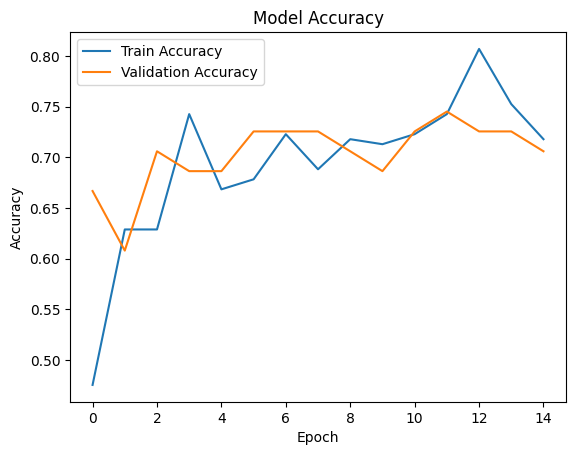

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

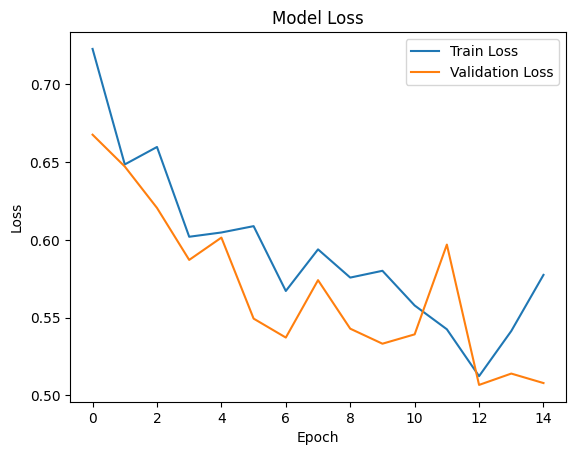

In [28]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [29]:
loss, accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7255 - loss: 0.5067
Test Accuracy: 72.55%


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = model.predict(test_data)
y_pred = (predictions > 0.5).astype(int)

print(classification_report(
    test_data.classes,
    y_pred
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        20
           1       0.77      0.77      0.77        31

    accuracy                           0.73        51
   macro avg       0.71      0.71      0.71        51
weighted avg       0.73      0.73      0.73        51



In [31]:
print(confusion_matrix(
    test_data.classes,
    y_pred
))

[[13  7]
 [ 7 24]]


In [32]:
model.save("brain_tumor_model_fixed.h5")

In [34]:
from google.colab import files

files.download("brain_tumor_model_fixed.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>